In [1]:
!pip install Kaggle

In [3]:
import os, shutil

# kaggle.json setup - works in Colab AND on a local machine.
# A missing kaggle.json is only fatal if the dataset is missing too.
kaggle_dir = os.path.expanduser("~/.kaggle")
have_key = os.path.exists(os.path.join(kaggle_dir, "kaggle.json"))

if os.path.isdir("/content") and not have_key:        # Google Colab -> prompt upload
    try:
        from google.colab import files
        uploaded = files.upload()                      # upload kaggle.json when prompted
        if uploaded:
            os.makedirs(kaggle_dir, exist_ok=True)
            shutil.copy("kaggle.json", os.path.join(kaggle_dir, "kaggle.json"))
            have_key = True
    except Exception as e:
        print("Upload skipped:", e)
elif not have_key and os.path.exists("kaggle.json"):   # local -> file next to the notebook
    os.makedirs(kaggle_dir, exist_ok=True)
    shutil.copy("kaggle.json", os.path.join(kaggle_dir, "kaggle.json"))
    have_key = True

if os.name != "nt" and have_key:
    os.chmod(os.path.join(kaggle_dir, "kaggle.json"), 0o600)

if have_key:
    print("kaggle.json ready in", kaggle_dir)
else:
    print("kaggle.json not found - that is fine if the dataset folder already exists.")
    print("Otherwise: place kaggle.json next to this notebook (or run in Colab), then re-run.")


kaggle.json not found - that is fine if the dataset folder already exists.
Otherwise: place kaggle.json next to this notebook (or run in Colab), then re-run.


In [4]:
import os

if any(os.path.isdir(d) for d in ["standardized_256", "standardized_384"]):
    print("Dataset already present - skipping download.")
else:
    print("Downloading dataset from Kaggle...")
    !kaggle datasets download -d sumn2u/garbage-classification-v2
    !unzip -q -o garbage-classification-v2.zip


Dataset URL: https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2
License(s): MIT
100% 1.07G/1.07G [00:16<00:00, 68.2MB/s]



In [5]:
!pip install tensorflow opencv-python scikit-learn matplotlib seaborn fastapi uvicorn python-multipart

## Data Importation


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
import cv2
from PIL import Image
import json
from collections import defaultdict
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
import torch
import torch.nn as nn

In [8]:
print("="*60)
print("CHECKING SETUP")
print("="*60)
print(f"TensorFlow version: {tf.__version__}")
gpu_available = len(tf.config.list_physical_devices('GPU')) > 0
print(f"GPU Available: {gpu_available}")
if gpu_available:
    print(f"GPU Device: {tf.config.list_physical_devices('GPU')[0].name}")
else:
    print(" No GPU - training will be SLOW. Switch to GPU in Colab: Runtime → Change Runtime Type → T4")

print("✓ Imports successful")

CHECKING SETUP
TensorFlow version: 2.20.0
GPU Available: True
GPU Device: /physical_device:GPU:0
✓ Imports successful


In [9]:
# Verify GPU is working
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("="*60)
print("GPU VERIFICATION")
print("="*60)
print(f"Number of GPUs: {len(gpus)}")

if len(gpus) > 0:
    print(f"✓ GPU Device: {gpus[0].name}")
    print("✓ GPU IS ACTIVE - Training will be FAST!")

    # Show GPU memory
    print(f"\nGPU Memory:")
    for gpu in gpus:
        print(f"  {gpu}")
else:
    print("✗ Still no GPU. Try:")
    print("  1. Runtime → Restart runtime")
    print("  2. Then Runtime → Change Runtime Type → T4")

GPU VERIFICATION
Number of GPUs: 1
✓ GPU Device: /physical_device:GPU:0
✓ GPU IS ACTIVE - Training will be FAST!

GPU Memory:
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [10]:
import os, zipfile, subprocess

# Locate (or download) the dataset once and set DATA_DIR for the whole notebook
CANDIDATES = ["standardized_256", "standardized_384"]
DATA_DIR = next((d for d in CANDIDATES if os.path.isdir(d)), None)

if DATA_DIR is None:
    print("No standardized_* folder found - downloading dataset from Kaggle...")
    if not os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")):
        raise FileNotFoundError("kaggle.json missing - run the kaggle.json setup cell above first.")
    subprocess.run(["kaggle", "datasets", "download", "-d",
                    "sumn2u/garbage-classification-v2", "-p", ".", "--force"], check=True)
    with zipfile.ZipFile("garbage-classification-v2.zip") as z:
        z.extractall(".")
    DATA_DIR = next((d for d in CANDIDATES if os.path.isdir(d)), None)

assert DATA_DIR is not None, ("Dataset still missing. Folders here: " + str(sorted(os.listdir("."))))
print("DATA_DIR =", DATA_DIR)


DATA_DIR = standardized_256


In [11]:
categories = sorted(d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d)))
class_counts = {}
for cat in categories:
    path = os.path.join(DATA_DIR, cat)
    class_counts[cat] = len([f for f in os.listdir(path)
                             if f.lower().endswith((".jpg", ".jpeg", ".png"))])

print("Categories and image counts:")
for cat, n in class_counts.items():
    print(f"  {cat}: {n}")
print()
print(f"Total images: {sum(class_counts.values())}")
print(f"Class imbalance ratio (max/min): {max(class_counts.values()) / min(class_counts.values()):.2f}x")

# DataFrame for the cells below (describe / countplot / imbalance ratio)
df = pd.DataFrame(sorted(class_counts.items()), columns=["Category", "Count"])
print(df)


Categories and image counts:
  battery: 756
  biological: 699
  cardboard: 1411
  clothes: 1892
  glass: 1736
  metal: 930
  paper: 1336
  plastic: 1597
  shoes: 1449
  trash: 453

Total images: 12259
Class imbalance ratio (max/min): 4.18x
     Category  Count
0     battery    756
1  biological    699
2   cardboard   1411
3     clothes   1892
4       glass   1736
5       metal    930
6       paper   1336
7     plastic   1597
8       shoes   1449
9       trash    453


In [12]:
data = {
    'battery': 756,
    'biological': 699,
    'cardboard': 1411,
    'clothes': 1892,
    'glass': 1736,
    'metal': 930,
    'paper': 1336,
    'plastic': 1597,
    'shoes': 1449,
    'trash': 453,

  }

df = pd.DataFrame(list(data.items()),columns=["Category","Count"])

print("Class distribution:\n",df)

Class distribution:
      Category  Count
0     battery    756
1  biological    699
2   cardboard   1411
3     clothes   1892
4       glass   1736
5       metal    930
6       paper   1336
7     plastic   1597
8       shoes   1449
9       trash    453


In [13]:
df.describe()

,Count
count,10.000000
mean,1225.900000
std,485.469406
min,453.000000
25%,799.500000
50%,1373.500000
75%,1560.000000
max,1892.000000


/tmp/ipykernel_536/2301910404.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category", y="Count", data=df, palette="viridis")


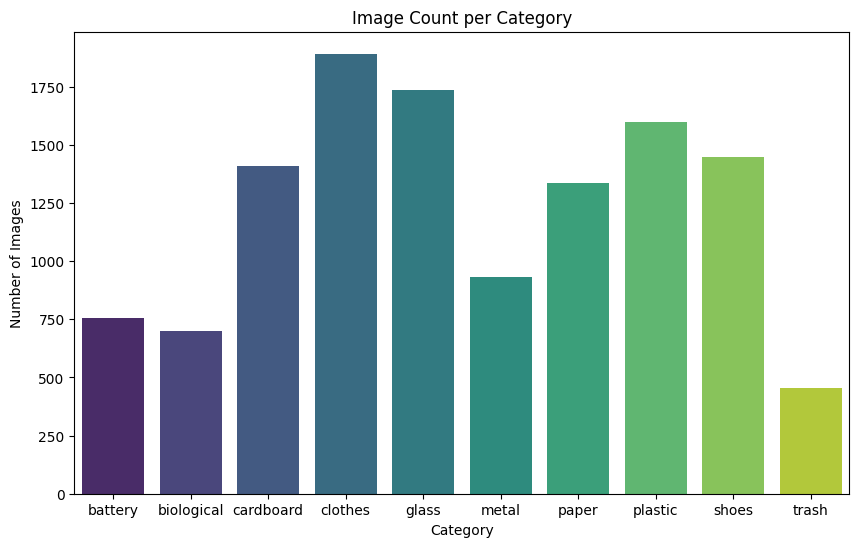

In [14]:
#Countplot
plt.figure(figsize=(10,6))
sns.barplot(x="Category", y="Count", data=df, palette="viridis")
plt.title("Image Count per Category")
plt.ylabel("Number of Images")
plt.show()

In [15]:
imbalance_ratio = df["Count"].max() / df["Count"].min()
print(f"Total images: {df['Count'].sum()}")
print(f"Class imbalance ratio (max/min): {imbalance_ratio:.2f}x")

Total images: 12259
Class imbalance ratio (max/min): 4.18x


In [16]:
# Handling class imbalance -- class weights in Keras format
counts = {
    'battery': 756, 'biological': 699, 'cardboard': 1411, 'clothes': 1892,
    'glass': 1736, 'metal': 930, 'paper': 1336, 'plastic': 1597,
    'shoes': 1449, 'trash': 453
}
total = sum(counts.values())
class_weight = {i: total / (len(counts) * n) for i, (_, n) in enumerate(sorted(counts.items()))}
print("Class weights (index -> weight):")
for k, v in class_weight.items():
    print(f"  {k}: {v:.3f}")
# Pass to model.fit(class_weight=class_weight) below


Class weights (index -> weight):
  0: 1.622
  1: 1.754
  2: 0.869
  3: 0.648
  4: 0.706
  5: 1.318
  6: 0.918
  7: 0.768
  8: 0.846
  9: 2.706


In [17]:
# Data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range = 20,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    shear_range =0.1,
    zoom_range = 0.1,
    horizontal_flip= True,
    fill_mode = 'nearest'
)

Found 12259 images belonging to 10 classes.


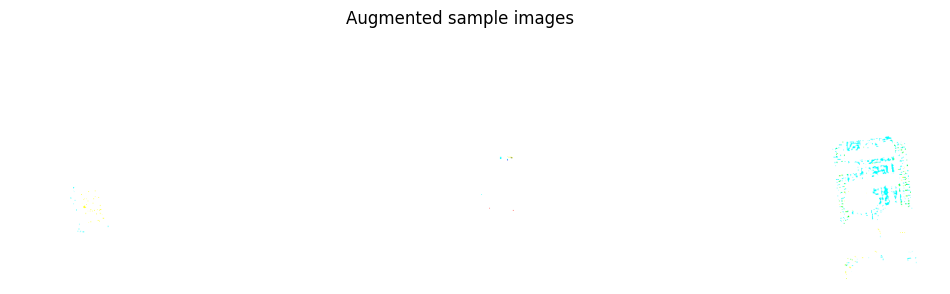

In [18]:
# Visualize what the augmentation pipeline produces (for the report)
aug_preview = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(224, 224),
    batch_size=5,
    class_mode="categorical",
    shuffle=True
)
imgs, _ = next(aug_preview)
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(imgs[i])
    plt.axis("off")
plt.suptitle("Augmented sample images")
plt.show()


## Build Model


In [19]:
print(sorted(os.listdir(DATA_DIR)))


['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [20]:
#Data preparation
train_datagen = ImageDataGenerator(
    preprocessing_function= preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    validation_split = 0.2
)

val_datagen =ImageDataGenerator(
     preprocessing_function= preprocess_input,
     validation_split=0.2
)
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode = "categorical",
    subset = "training"
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False  # REQUIRED: keeps y_true aligned with predictions
)

Found 9811 images belonging to 10 classes.
Found 2448 images belonging to 10 classes.


In [21]:
IMG_SIZE=(224,224)
NUM_CLASSES = len(val_generator.class_indices)

base_model= MobileNetV2(
    weights="imagenet",
    include_top = False,
    input_shape =IMG_SIZE + (3,),
)

base_model.trainable = False

inputs = layers.Input(shape = IMG_SIZE + (3,))
x = base_model(inputs,training= False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128,activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES,activation="softmax")(x)

model =Model(inputs,outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
              )
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor="val_loss", factor=0.3,patience=2,min_lr=1e-6)


In [24]:
print("train batches:",len(train_generator))
print("val_batches:",len(val_generator))

train batches: 307
val_batches: 77


In [25]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weight,   # rebalances loss for minority classes
    callbacks=[early_stop,lr_reduce],
)


Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 224s 662ms/step - accuracy: 0.6940 - loss: 0.9354 - val_accuracy: 0.8448 - val_loss: 0.4702 - learning_rate: 0.0010
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 174s 569ms/step - accuracy: 0.8053 - loss: 0.5765 - val_accuracy: 0.8570 - val_loss: 0.4160 - learning_rate: 0.0010
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 176s 572ms/step - accuracy: 0.8292 - loss: 0.5211 - val_accuracy: 0.8701 - val_loss: 0.4120 - learning_rate: 0.0010
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 182s 593ms/step - accuracy: 0.8384 - loss: 0.4671 - val_accuracy: 0.8799 - val_loss: 0.3710 - learning_rate: 0.0010
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 174s 568ms/step - accuracy: 0.8480 - loss: 0.4457 - val_accuracy: 0.8705 - val_loss: 0.3829 - learning_rate: 0.0010
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 179s 583ms/step - accuracy: 0.8516 - loss: 0.4267 - val_accuracy: 0.8873 - val_loss: 0.3476 - learning_rate: 0.0010
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 178s 580ms/step - accura

In [26]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
  layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate= 1e-5),
    loss= "categorical_crossentropy",
    metrics=["accuracy"],
)

In [27]:
#fine_tuining
history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weight,   # rebalances loss for minority classes
    callbacks=[early_stop,lr_reduce],
)


Epoch 1/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 211s 629ms/step - accuracy: 0.8076 - loss: 0.5501 - val_accuracy: 0.8922 - val_loss: 0.3353 - learning_rate: 1.0000e-05
Epoch 2/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 171s 556ms/step - accuracy: 0.8412 - loss: 0.4642 - val_accuracy: 0.8873 - val_loss: 0.3406 - learning_rate: 1.0000e-05
Epoch 3/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 173s 564ms/step - accuracy: 0.8507 - loss: 0.4330 - val_accuracy: 0.8901 - val_loss: 0.3430 - learning_rate: 1.0000e-05
Epoch 4/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 174s 567ms/step - accuracy: 0.8591 - loss: 0.3962 - val_accuracy: 0.8905 - val_loss: 0.3327 - learning_rate: 3.0000e-06
Epoch 5/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 175s 570ms/step - accuracy: 0.8645 - loss: 0.3844 - val_accuracy: 0.8864 - val_loss: 0.3618 - learning_rate: 3.0000e-06


In [28]:
# Predictions -- val_generator has shuffle=False, so .labels aligns with the
# order in which model.predict() walks the generator
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.labels
assert len(y_true) == len(y_pred_classes), "Label/prediction misalignment!"


77/77 ━━━━━━━━━━━━━━━━━━━━ 43s 496ms/step


In [29]:
print(classification_report(y_true,y_pred_classes, target_names=list(val_generator.class_indices.keys())))

              precision    recall  f1-score   support

     battery       0.88      0.98      0.93       151
  biological       0.93      0.98      0.95       139
   cardboard       0.91      0.88      0.89       282
     clothes       0.98      0.98      0.98       378
       glass       0.91      0.82      0.86       347
       metal       0.76      0.90      0.82       186
       paper       0.84      0.85      0.84       267
     plastic       0.88      0.81      0.84       319
       shoes       0.97      0.94      0.96       289
       trash       0.65      0.81      0.72        90

    accuracy                           0.89      2448
   macro avg       0.87      0.89      0.88      2448
weighted avg       0.90      0.89      0.89      2448



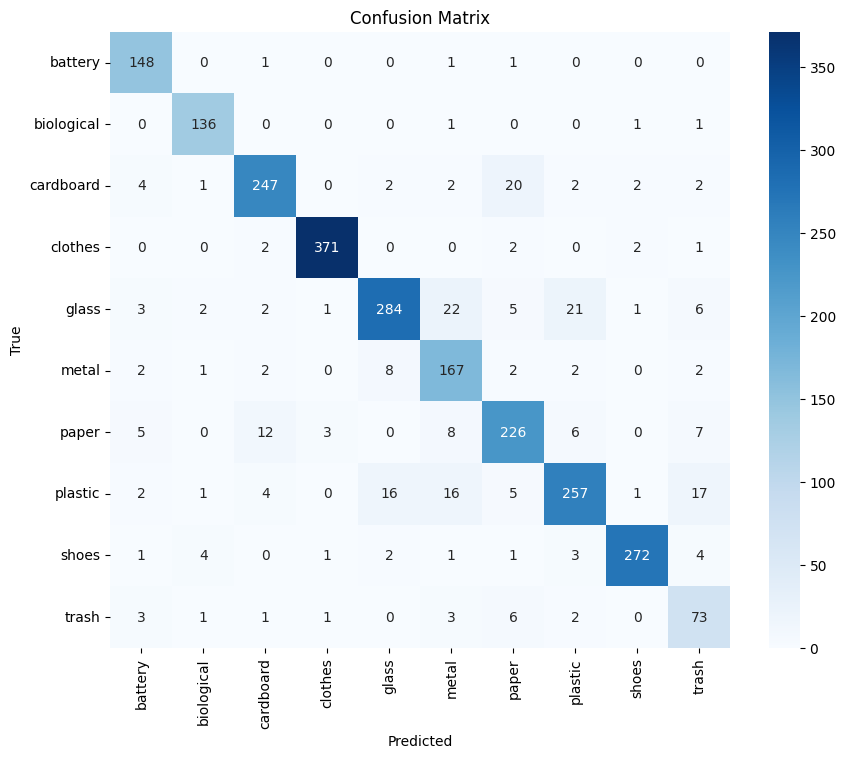

In [30]:
##Confusion Matrix
cm = confusion_matrix(y_true,y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(val_generator.class_indices.keys()),
            yticklabels=list(val_generator.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [31]:
##Save model
model.save('my_model.keras')

## Training Curves

## Safety-Critical Analysis: Battery False Negatives

A false negative on **battery** (hazardous material) is costlier than a false positive, so raw accuracy is not the right headline metric. We report battery recall explicitly, plus per-class recall for other hazardous/minority classes.

In [32]:
report = classification_report(
    y_true, y_pred_classes,
    target_names=list(val_generator.class_indices.keys()),
    output_dict=True
)
print(f"Overall accuracy: {report['accuracy']:.2%}")
print(f"Macro F1: {report['macro avg']['f1-score']:.2%}")
print()
for cls in ['battery', 'biological', 'metal', 'trash']:
    print(f"Recall for {cls}: {report[cls]['recall']:.2%}")
print()
batt = report['battery']['recall']
print(f"Battery recall (safety-critical): {batt:.2%} -- "
      + ("acceptable" if batt >= 0.9 else "BELOW the 90% target; route low-confidence battery predictions to a human sorter"))


Overall accuracy: 89.09%
Macro F1: 88.03%

Recall for battery: 98.01%
Recall for biological: 97.84%
Recall for metal: 89.78%
Recall for trash: 81.11%

Battery recall (safety-critical): 98.01% -- acceptable
